In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import easyMPRA_20231120 as em
from _helper_functions import *

loading libraries...
done!


In [2]:
dnaMinRpmThresh=0.05 # do not consider any barcodes with RPM <.05
minDnaBc=5 # do not consider any enhancers with less than 5 barcodes per enhancer
minNumRepsDetectedRna=3 # to consider an enhancer in the analysis, require it is detected in at least 3 replicates
ratioAggFuncTuple2minActivityToCount={'mean':1.5} # require the enhancer has a minimum of 1.5 activity. anything below this is noise


In [3]:
endf=pd.read_pickle(f'01-Barcode-Processing/endf.pd.df.pickle')

In [4]:
len(endf)

3318

In [5]:
endf.head(1)

,enhancer-seq,enhancer-id,barcode-seq,rpm-D1,rpm-D2,rpm-D3,rpm-D4,rpm-R1,rpm-R2,rpm-R3,rpm-R4,rpm-D5,rpm-D6,rpm-D7,rpm-R5,rpm-R6,rpm-R7
0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAG...,Chr8:6147080-6147146,"[TTGCTAACACGATTGCGGATCGATT, ACTTATCTACTGACTGTC...","[0.220733824144946, 0.23371713495616817, 0.155...","[0.28989230073817873, 0.24411855465032495, 0.1...","[0.2338136718273605, 0.37410018092653813, 0.14...","[0.31803960026920236, 0.3066798448131834, 0.12...","[nan, nan, nan, nan, nan, nan, 5.2038925315859...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.24875336076715374, 0.4168281875893575, 0.14...","[0.2383559015027607, 0.33546243691143335, 0.13...","[0.22696320104904208, 0.36313963813044275, 0.0...","[nan, nan, nan, nan, nan, nan, nan, nan, 1.382...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, 9.6506626635407..."


In [6]:
# this dictionary allows us to access the different samples in for loops
SampleScaffoldKey2ValueList={
    '{nt}':['R','D'],
    '{rep}':['1','2','3','4','5','6','7'],
}


In [7]:


scaffold='rpm-{nt}{rep}'

for rep in SampleScaffoldKey2ValueList['{rep}']:
    
    print(rep)
    
    # without dna rpm min rilter
    dna=scaffold.replace('{nt}','D').replace('{rep}',rep)
    rna=scaffold.replace('{nt}','R').replace('{rep}',rep)
    
    endf[rna+'-filtNa-Dnotnull'],\
    endf[dna+'-filtNa-Dnotnull']=\
    em.filter_na_matched(indf=endf,
                         col1=rna,
                         col2=dna,
                         treatNaType={rna:'zero',dna:'omit'})
    
    # dna rpm min rilter

    endf[dna+f'-minDnaRpm{dnaMinRpmThresh}']=em.mask_na_filter(endf,dna,filterType='min',minVal=dnaMinRpmThresh)
    
    endf[rna+f'-minDnaRpm{dnaMinRpmThresh}'+'-filtNa-Dnotnull'],\
    endf[dna+f'-minDnaRpm{dnaMinRpmThresh}'+'-filtNa-Dnotnull']=\
    em.filter_na_matched(indf=endf,
                         col1=rna,
                         col2=dna+f'-minDnaRpm{dnaMinRpmThresh}',
                         treatNaType={rna:'zero',dna+f'-minDnaRpm{dnaMinRpmThresh}':'omit'})


1
2
3
4
5
6
7


# filter out any enhancers with <5 dna barcodes

In [8]:


scaffold = f'rpm-{{nt}}{{rep}}-minDnaRpm{dnaMinRpmThresh}-filtNa-Dnotnull'
    
for rep in SampleScaffoldKey2ValueList['{rep}']:

    print(rep)

    thisColDNA=scaffold.replace('{nt}','D').replace('{rep}',rep)
    thisColRNA=scaffold.replace('{nt}','R').replace('{rep}',rep)

    thisColDNAOut=thisColDNA+f'-minDnaBc{minDnaBc}'
    thisColRNAOut=thisColRNA+f'-minDnaBc{minDnaBc}'

    endf[thisColDNAOut]=endf.apply(lambda row: row[thisColDNA] if len(row[thisColDNA])>=minDnaBc else [],axis=1)
    endf[thisColRNAOut]=endf.apply(lambda row: row[thisColRNA] if len(row[thisColDNA])>=minDnaBc else [],axis=1)




1
2
3
4
5
6
7


In [9]:
def _opwrapper(l,func,omitna=True,null=np.NaN):
    # remove na if desired
    if omitna:    l=[li for li in l if not pd.isnull(li)]
    
    # 
    if len(l)>=1: return func(l)
    else:         return null

def _sum(l):
    return _opwrapper(l,func=sum,null=0)

def _max(l):
    return _opwrapper(l,func=max,null=0)

def _mean(l):
    return _opwrapper(l,func=np.mean,null=0)

In [10]:

# ratio 

aggfunc,agglabel=_mean,'mean' # aggregate within each rep by taking the mean of all RNA:DNA ratios, ignoring NA values

scaffold=f'rpm-{{nt}}{{rep}}' 
filtstyle=f'-minDnaRpm{dnaMinRpmThresh}-filtNa-Dnotnull-minDnaBc{minDnaBc}'
allRepsString='1234567'
        
# calculat reps individually
for rep in SampleScaffoldKey2ValueList['{rep}']:

    rna = scaffold.replace('{nt}','R').replace('{rep}',rep) + filtstyle
    dna = scaffold.replace('{nt}','D').replace('{rep}',rep) + filtstyle

    listcol=f'ratio-replist-{rep}{filtstyle}'

    endf[listcol] = \
    em.aggregate_matched_across_samples(indf=endf, 
                                        col1=rna, 
                                        col2=dna, 
                                        aggfunc=em.ratio)

    aggcol=f'ratio-repagg-{rep}{filtstyle}-{agglabel}'
    endf[aggcol] = \
    em.aggregate_within_samples(indf=endf,col=listcol,aggfunc=aggfunc)

# aggregate reps
minActivityToCount=ratioAggFuncTuple2minActivityToCount[agglabel]
expWideScaffold=f'ratio-repagg-{{rep}}{filtstyle}-{agglabel}'
colsToCombine=em.label_generator(expWideScaffold,SampleScaffoldKey2ValueList,'{rep}',endf.columns)

# takes sum of acitivity-wide replicate to get an expirement-wide activity score
allRepsString=''.join(SampleScaffoldKey2ValueList['{rep}'])
endf[f'ratio-expagg-{allRepsString}{filtstyle}-{agglabel}'] = em.concat_sample_values(endf,colsToCombine)
endf[f'ratio-expagg-{allRepsString}{filtstyle}-{agglabel}-minActFilt{minActivityToCount}'] = em.mask_na_filter(endf,f'ratio-expagg-{allRepsString}{filtstyle}-{agglabel}',minVal=minActivityToCount,filterType='min')


endf[f'ratio-expagg-{allRepsString}{filtstyle}-{agglabel}-minActFilt{minActivityToCount}-minRepsActObs{minNumRepsDetectedRna}-expsum'] = endf[f'ratio-expagg-{allRepsString}{filtstyle}-{agglabel}-minActFilt{minActivityToCount}'].apply(lambda l: sum    ([li for li in l if pd.notnull(li)]) if len([li for li in l if pd.notnull(li)])>=minNumRepsDetectedRna else np.NaN)

In [22]:
endf.head(1)

,enhancer-seq,enhancer-id,barcode-seq,rpm-D1,rpm-D2,rpm-D3,rpm-D4,rpm-R1,rpm-R2,rpm-R3,rpm-R4,rpm-D5,rpm-D6,rpm-D7,rpm-R5,rpm-R6,rpm-R7,rpm-R1-filtNa-Dnotnull,rpm-D1-filtNa-Dnotnull,rpm-D1-minDnaRpm0.05,rpm-R1-minDnaRpm0.05-filtNa-Dnotnull,rpm-D1-minDnaRpm0.05-filtNa-Dnotnull,rpm-R2-filtNa-Dnotnull,rpm-D2-filtNa-Dnotnull,rpm-D2-minDnaRpm0.05,rpm-R2-minDnaRpm0.05-filtNa-Dnotnull,rpm-D2-minDnaRpm0.05-filtNa-Dnotnull,rpm-R3-filtNa-Dnotnull,rpm-D3-filtNa-Dnotnull,rpm-D3-minDnaRpm0.05,rpm-R3-minDnaRpm0.05-filtNa-Dnotnull,rpm-D3-minDnaRpm0.05-filtNa-Dnotnull,rpm-R4-filtNa-Dnotnull,rpm-D4-filtNa-Dnotnull,rpm-D4-minDnaRpm0.05,rpm-R4-minDnaRpm0.05-filtNa-Dnotnull,rpm-D4-minDnaRpm0.05-filtNa-Dnotnull,rpm-R5-filtNa-Dnotnull,rpm-D5-filtNa-Dnotnull,rpm-D5-minDnaRpm0.05,rpm-R5-minDnaRpm0.05-filtNa-Dnotnull,rpm-D5-minDnaRpm0.05-filtNa-Dnotnull,rpm-R6-filtNa-Dnotnull,rpm-D6-filtNa-Dnotnull,rpm-D6-minDnaRpm0.05,rpm-R6-minDnaRpm0.05-filtNa-Dnotnull,rpm-D6-minDnaRpm0.05-filtNa-Dnotnull,rpm-R7-filtNa-Dnotnull,rpm-D7-filtNa-Dnotnull,rpm-D7-minDnaRpm0.05,rpm-R7-minDnaRpm0.05-filtNa-Dnotnull,rpm-D7-minDnaRpm0.05-filtNa-Dnotnull,rpm-D1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-D7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,rpm-R7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-replist-1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-replist-7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5,ratio-repagg-7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean,ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5,ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum
0,AAAAAACTTGAAATCGCGTCTTATGCAACTGTAAATCCGGGAGCAGATAAATACACAAATATCCTG,Chr8:6147080-6147146,"[TTGCTAACACGATTGCGGATCGATT, ACTTATCTACTGACTGTCCTCGCCT, TTTTGTATCAAGCTTGTGGGACCCG, GCTATGTTATCTGC...","[0.220733824144946, 0.23371713495616817, 0.15564169227966881, 0.4924309922433955, 0.038875310318...","[0.28989230073817873, 0.24411855465032495, 0.15240996659371667, 0.3197764512875319, 0.0304542638...","[0.2338136718273605, 0.37410018092653813, 0.14791915315194892, 0.35002404587412034, 0.0855597031...","[0.31803960026920236, 0.3066798448131834, 0.12480684722132872, 0.24939225940386225, 0.0906861328...","[nan, nan, nan, nan, nan, nan, 5.203892531585922, nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]","[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]","[0.24875336076715374, 0.4168281875893575, 0.14103134625158528, 0.2751050225165744, 0.06038769179...","[0.2383559015027607, 0.33546243691143335, 0.1322768504744334, 0.387672671610621, 0.0792950626638...","[0.22696320104904208, 0.36313963813044275, 0.0680153362189268, 0.24917099864919873, 0.03

# rescale activity so <0 is inert and >1 is active

In [11]:

minRepsActObs=3
dnaMinRpmThresh=.05
minSumRnaSumDnaFilt=1.5
minDnaBc=5
pctlmin,pctlmax=(55,65)
aggfunc1='mean'
aggfunc2='sum'

activityColFinal=f'ratio-expagg-1234567-minDnaRpm{dnaMinRpmThresh}-filtNa-Dnotnull-minDnaBc{minDnaBc}-{aggfunc1}-minActFilt{minSumRnaSumDnaFilt}-minRepsActObs{minRepsActObs}-exp{aggfunc2}'     
endf[activityColFinal+'-log2']=endf[activityColFinal].apply(lambda a: np.log2(a) if a!=0 else np.NaN)


In [12]:
Func2Color={'Neural + Ectopic': cb['pink'],
 'Neural': cb['green'],
 'Inert': cb['orangenature'],
}

skipControls=['Not Tested','Weak Neural','Inert - No Counting','Nueral - No Counting']

In [13]:
# rescale based on dual cutoffs
activityColName=activityColFinal+'-log2'

activityName=activityColName

plotTitle=''

thresholdToLabelPositives = np.percentile(endf[activityColName].dropna(), pctlmax)
thresholdToLabelNegatives = np.percentile(endf[activityColName].dropna(), pctlmin)

log2transformactivity=False
ymin,ymax=-5,3

printBadControls=False
plot_legend=False

subsampleviolin=False
scaling_range = thresholdToLabelPositives - thresholdToLabelNegatives
endf[activityColName+f'-rescaled-minpctl{pctlmin}-maxpctl{pctlmax}'] = endf[activityColName].apply(lambda a:(a - thresholdToLabelNegatives) / scaling_range)



log2 thresholds
4.38423924579468
4.100355437299692



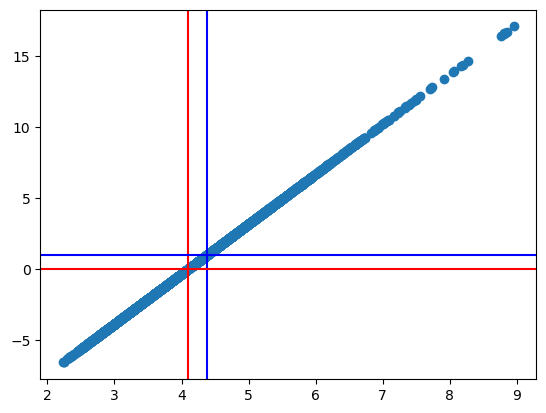

In [14]:
# show repro of rescaling

# show that the scaling is correct
fig,ax=plt.subplots(1)

ax.scatter(endf[activityColName],endf[activityColName+f'-rescaled-minpctl{pctlmin}-maxpctl{pctlmax}'])
ax.axvline(thresholdToLabelNegatives,color='red')
ax.axvline(thresholdToLabelPositives,color='blue')
ax.axhline(0,color='red')
ax.axhline(1,color='blue')

In [15]:
activityColName=activityColName+f'-rescaled-minpctl{pctlmin}-maxpctl{pctlmax}'


In [16]:
outcols=['enhancer-seq','enhancer-id','barcode-seq','ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean-minActFilt1.5-minRepsActObs3-expsum-log2-rescaled-minpctl55-maxpctl65']


fn=f'01-Barcode-Processing/endf_final-experiment-enhancer-activity'
endf.to_pickle(fn+'.pd.df.pickle')
endf.to_csv(fn+'.tsv',sep='\t',index=None)

# Plotting activity of known controls

In [29]:
# # load controls
# cdf=pd.read_csv('../data/OLS100-functional-classifications_curated_forRelToWtComparisons.tsv',sep='\t')
# cdf.head()

In [30]:
# map sequence to control ref info

# fn='../data/Ols100Enhancer2Name.pydict.pickle'
# with open(fn,'rb') as f: Ols100Enhancer2Name=pickle.load(f)
    
# Ols100Name2Enhancer={v:k for k,v in Ols100Enhancer2Name.items()}
# dprint(Ols100Enhancer2Name)

# Ols100Enhancer2Name={}
# Ols100Enhancer2FxnalGroup={}

# for seq,name,func,ctrltype,notes in zipdf(cdf,['Seq', 'Name', 'Func', 'Control Type', 'Reason Omitted / Stipulations if retained']):
#     Ols100Enhancer2Name[seq]=name
#     Ols100Name2Enhancer[name]=seq
#     Ols100Enhancer2FxnalGroup[seq]=func

fn='../../../otxa-scrambled-constant/0-redo-analysis-for-nature-submission/1-rna-dna-bulk/data/all-control-names-and-sequences.Ols100Enhancer2Name.pydict.pickle'
with open(fn,'rb') as f: Ols100Enhancer2Name=pickle.load(f)

fn='../../../otxa-scrambled-constant/0-redo-analysis-for-nature-submission/1-rna-dna-bulk/data/20230926-Moderate-controls-ols-100_MicroscopeSeq2Func.pydict.pickle'
with open(fn,'rb') as f: Ols100Enhancer2FxnalGroup=pickle.load(f)

# Ols100Enhancer2Name['CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA']='OLS WT'
# Ols100Enhancer2Name['CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATTGCTCAATATTTAAAATAGGA']='OLS WT_ablatedGataEts'

# Ols100Enhancer2FxnalGroup['CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA']='Neural'
# Ols100Enhancer2FxnalGroup['CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATTGCTCAATATTTAAAATAGGA']='Inert'

dprint(Ols100Enhancer2Name)
dprint(Ols100Enhancer2FxnalGroup)




CCTATCTTTGCTCGAGATAACCATCTGAAGCTCATTTCCTTTTTCGAAAGATATTTAACGGAAGTA MOLS 1
CCTATCTTTGCTCGAGATAACCATCTGAAGCTCATTTCCTTTTTCGAAAGATATTTAACGGAAGTA Neural


In [31]:
# load og variants
# froom projects/otxa/otxa-scrambled-constant/0-redo-analysis-for-nature-submission/1-rna-dna-bulk/09b_PRE_20230926_Predictions-all-lib-seqs__Testing.ipynb

fn='ref/MicroscopeGroup2Seq.pydict.pickle'
MicroscopeGroup2Seq=load_pickle_dict(fn)

fn='ref/MicroscopeSeq2Func.pydict.pickle'
MicroscopeSeq2Func=load_pickle_dict(fn)

fn='ref/MicroscopeSeq2Name.pydict.pickle'
MicroscopeSeq2Name=load_pickle_dict(fn)
MicroscopeName2Seq={v:k for k,v in MicroscopeSeq2Name.items()}

In [32]:
dprint(MicroscopeName2Seq)

Dr1 GTAGTTTTTCCAGTTGCGATATTTTTGGTATTTATCTTCAGGAAATCACTAAAGGCATGTTATCTT


In [33]:
MicroscopeName2Seq.keys()

dict_keys(['Dr1', 'Dr2', 'GC1', 'GC2', 'GC3', 'GC4', 'Ggd1', 'Hs1', 'Hs10', 'Hs2', 'Hs3', 'Hs4A', 'Hs4B', 'Hs5A', 'Hs5B', 'Hs8A', 'Hs8B', 'Hs9', 'Mm1', 'Mm2', 'Mm6', 'SC1', 'SC2', 'SC3', 'WTFE', 'WTFG', 'Otxa WT', 'ZEE29_SE1', 'ZEE29_SE2', 'ZEE29_SE4', 'ZEE29_SE5', 'ZEE36_SE3', 'ZEE36_SE4', 'ZEE36_SE6', 'ZEE36_SE7', 'OG-FA', 'OG-RB', 'OG-RC', 'OG-RD', 'OG-RK', 'OG-RL', 'OG-RM', 'OG-RN', 'OG1', 'OG3', 'OG4', 'OG5', 'OG8', 'OG2mut', 'OG9'])

In [34]:
# controls=['OLS 41','OLS 85','OG-RC','OLS 12','OLS 19','OLS 11','OLS 22','OLS 29'] #41 is abl
# controls=['OG-RC'] #copeName2Seq[ci])

In [35]:
fn='/tscc/nfs/home/solvason/projects/otxa/otxa-scrambled-constant/0-redo-analysis-for-nature-submission/1-rna-dna-bulk/data/20230925-all-control-names-and-sequences.MicroscopeName2Seq.pydict.pickle'
olsMicroscopeName2Seq=load_pickle_dict(fn)


In [36]:
controls=['OLS 41 ABL','OLS 85','OG-RC','OLS 12','OLS 19','OLS 11','OLS 22','OLS 29'] #41 is abl
for ci in controls:
    print(ci,olsMicroscopeName2Seq[ci])

OLS 41 ABL CATCTGAAGCTCGTTATTTCTGCTCCCTATTTTTTTCGAAATTTGCTTTAACTTGCGTAAATATTA
OLS 85 TGCTCAAGGAAATCATCTGAAGCTCACTTCCGTAGATATTTAGTTATCTCTTTCGAAAAGATAGGA
OG-RC GATCTTTACTCGCACAAGAAGGAAGTATATCTTGCCTATGATAGCATCCTTGAGGTGATACCTGGA
OLS 12 CATCTGAAGCTCAATATCTTTTCGAAAAGGAAATTGCTCGAGATAACTAACGGAAGTCCTATCTTA
OLS 19 CATCTGAAGCTCATTTCCTTTTTCGAACCTATCTTTGCTCAATATCTACGGAAGTTAGAGATAACA
OLS 11 TAAAGGAAATTGCTCGAGATAACAAGATAGGCATCTGAAGCTCACTTCCGTTTTCGAAAGATATTA
OLS 22 CATCTGAAGCTCACGGAAGTAGATATTTGCTCAAGATAGGTTTCGAAATTTCCTTTAGAGATAACA
OLS 29 CATCTGAAGCTCGTTATCTCATTTCCTTTAAGATATTTGCTCACTTCCGTTTTCGAACCTATCTTA


In [37]:
# # append og variants to controls dataset
# seqsToAdd=MicroscopeGroup2Seq['OG Grammar Predict Neural']+MicroscopeGroup2Seq['OG Grammar Predict Inert']

# for g in ['OG Grammar Predict Neural','OG Grammar Predict Inert']:
#     for s in MicroscopeGroup2Seq[g]:

#         if s not in MicroscopeSeq2Name and revcomp(s) not in MicroscopeSeq2Name: 
#             print('[SEQ NOT FOUND IN OG DATA]')

#             if s not in endf['enhancer-seq']:
#                 print('\tBAD ==> SEQ ALSO NOT FOUND IN MPRA',s,g)
#             else:
#                 print('\tOK  ==> SEQ ALSO NOT FOUND IN MPRA')
        
#         else:
#             print('[OK]',MicroscopeSeq2Name[s])
#             Ols100Enhancer2Name[s]=MicroscopeSeq2Name[s]
#             Ols100Enhancer2FxnalGroup[s]=MicroscopeSeq2Func[s]

In [38]:
# js.write_dict(Ols100Enhancer2Name,'ref/Ols100Enhancer2Name.og.ols.pydict.pickle')
# Ols100Enhancer2Name


In [39]:
# js.write_dict(Ols100Enhancer2FxnalGroup,'ref/Ols100Enhancer2FxnalGroup.og.ols.pydict.pickle')
# Ols100Enhancer2FxnalGroup

In [40]:
# js.dprint(Ols100Enhancer2Name)

In [41]:
# js.dprint(Ols100Enhancer2FxnalGroup)

In [42]:
# Ols100Enhancer2Name['TCGATAATTACGTATCGCGGAAGTCGTGGAACGTAACTGCAAGGTCTGGAGCCAAACCAAACACCC']='Top Act En1'
# Ols100Enhancer2Name['AGAACTTTATCACAACGACTTCCAGAGAGTAAATTAATTAAAACACGATTAGAATATTTGGATAAT']='Top Act En2'
# Ols100Enhancer2Name['ATGGTGTAAGCTAGGTGTAAAAGGCGACAAGGAAGCGAGATAACGAAGGAGCGTGCGTCGGATAAA']='Top Act En3'
# Ols100Enhancer2Name['AAAATAGCCGGGAGGGATATCGCCGGTTGGAAAACGCCTGGGGGGATATAGCCTAGGCCCTAGACC']='Top Act En4'
# Ols100Enhancer2Name['AGGGATTATCGCTTCCATCGCTACACTTCGACACTCCGCTGATTAAACCGATCTTATCGATGCAAA']='Top Act En5'

# Ols100Enhancer2FxnalGroup['TCGATAATTACGTATCGCGGAAGTCGTGGAACGTAACTGCAAGGTCTGGAGCCAAACCAAACACCC']='Not Tested'
# Ols100Enhancer2FxnalGroup['AGAACTTTATCACAACGACTTCCAGAGAGTAAATTAATTAAAACACGATTAGAATATTTGGATAAT']='Not Tested'
# Ols100Enhancer2FxnalGroup['ATGGTGTAAGCTAGGTGTAAAAGGCGACAAGGAAGCGAGATAACGAAGGAGCGTGCGTCGGATAAA']='Not Tested'
# Ols100Enhancer2FxnalGroup['AAAATAGCCGGGAGGGATATCGCCGGTTGGAAAACGCCTGGGGGGATATAGCCTAGGCCCTAGACC']='Not Tested'
# Ols100Enhancer2FxnalGroup['AGGGATTATCGCTTCCATCGCTACACTTCGACACTCCGCTGATTAAACCGATCTTATCGATGCAAA']='Not Tested'

In [43]:
# js.write_dict(Ols100Enhancer2Name,'ref/Ols100Enhancer2Name.og.ols.topmpraens.pydict.pickle')
# Ols100Enhancer2Name


In [44]:
# js.write_dict(Ols100Enhancer2FxnalGroup,'ref/Ols100Enhancer2FxnalGroup.og.ols.topmpraens.pydict.pickle')
# Ols100Enhancer2FxnalGroup

In [45]:
# controlSeqs=set(Ols100Enhancer2Name.keys())
# mpraSeqs=set(endf['enhancer-seq'])

# len(controlSeqs),len(controlSeqs&mpraSeqs)

In [46]:

# print('controls in experiment')
# for seq in mpraSeqs&controlSeqs:
#     print(Ols100Enhancer2Name[seq],end=', ')

# print('\n\ncontrols in experiment')
# for seq in controlSeqs-mpraSeqs:
#     print(Ols100Enhancer2Name[seq],end=', ')

In [47]:

# g2c={}
# print('controls in experiment')
# for seq in mpraSeqs&controlSeqs:
#     g=Ols100Enhancer2FxnalGroup[seq]
#     if g not in g2c: g2c[g]=0
#     g2c[g]+=1

# print(g2c)
# g2c={}
# print('\n\ncontrols in experiment')
# for seq in controlSeqs-mpraSeqs:
#     if seq in Ols100Enhancer2FxnalGroup:
#         g=Ols100Enhancer2FxnalGroup[seq]
#         if g not in g2c: g2c[g]=0
#         g2c[g]+=1

#     else: 
#         print('no counting data for',Ols100Enhancer2Name[seq])

In [48]:
# fn='../../../otxa-scrambled-constant/0-redo-analysis-for-nature-submission/1-rna-dna-bulk/data/OlsEnSeq2Id.pydict.pickle'
# with open(fn,'rb') as f: OlsEnSeq2Id=pickle.load(f)
# dprint(OlsEnSeq2Id)

# endf['enhancer-id2']=endf['enhancer-seq'].apply(lambda seq: OlsEnSeq2Id[seq])

In [49]:
# add ref data to dataframe

ctrlfxn=[]
ctrlname=[]

for seq in endf['enhancer-seq']:
    if seq in Ols100Enhancer2FxnalGroup:   ctrlfxn.append(Ols100Enhancer2FxnalGroup[seq])
    else:                                  ctrlfxn.append(np.NaN)
        
    if seq in Ols100Enhancer2Name:         ctrlname.append(Ols100Enhancer2Name[seq])
    else:                                  ctrlname.append(np.NaN)

endf['CONTROL_FUNCTION_INITIAL']=ctrlfxn
endf['CONTROL_FUNCTION']=ctrlfxn
endf['CONTROL_NAME']=ctrlname

In [50]:
# endf.CONTROL_NAME.unique()

In [51]:
# # some plotting parameters

# Func2Color={
#     'Neural + Ectopic'     :cb['orange'],
#     'Neural'               :cb['blue'],      
#     'Weak Neural'          :cb['lightblue'],     
#     'Inert'                :cb['red'], 
#     'Inert - No Counting'  :'pink',
#     'Nueral - No Counting'  :'lightgreen',
#     # 'Non-Functional*'  : 'lightcoral',
#     # 'Neural Enhancer*' : 'blue', 
#     'Not Tested': 'grey',
# }     

# violinColors=['orange','green','lightgreen','red']

# Function2Binary={
#     'Neural + Ectopic'    :1,
#     'Neural'              :1,
#     'Weak Neural'         :1,
#     'Inert'               :0,
#     'Inert - No Counting'  :0,
#     'Nueral - No Counting'  :1,

# }     

# Func2Color

## a function to plot controls

In [52]:
# endf=endf.set_index('enhancer-id',drop=False)
# endf=endf.reset_index()
# endf.head(1)

In [54]:
# [c for c in endf.columns.tolist() if 'avg' in c]

## plot all possible activities

In [55]:
# endf.head(1)

In [56]:
# [c for c in endf.columns if 'pool' in c]

In [57]:
# actlist=[
#  'pool-lenRnonzero/lenD-avg-filtNa-Dnotnull',
#  'pool-lenRnonzero/lenD-avg-filtNa-Rnotnull-Dnotnull',
#  'ratio-expavg-filtNa-Dnotnull',
#  'ratio-expmax-filtNa-Dnotnull',
#  'ratio-expsum-filtNa-Dnotnull',
#  'ratio-expavg-filtNa-Rnotnull-Dnotnull',
#  'ratio-expmax-filtNa-Rnotnull-Dnotnull',
#  'ratio-expsum-filtNa-Rnotnull-Dnotnull',
#  'pool-sumR/sumD-min-filtNa-Dnotnull',
#  'pool-sumR/lenD-min-filtNa-Dnotnull',
#  'pool-sumR/sumD-min-filtNa-Rnotnull-Dnotnull',
#  'pool-sumR/lenD-min-filtNa-Rnotnull-Dnotnull',
#  'pool-sumR/sumD-avg-filtNa-Dnotnull',
#  'pool-sumR/sumD-max-filtNa-Dnotnull',
#  'pool-sumR/sumD-sum-filtNa-Dnotnull',
#  'pool-sumR/lenD-avg-filtNa-Dnotnull',
#  'pool-sumR/lenD-max-filtNa-Dnotnull',
#  'pool-sumR/lenD-sum-filtNa-Dnotnull',
#  'pool-sumR/sumD-avg-filtNa-Rnotnull-Dnotnull',
#  'pool-sumR/sumD-max-filtNa-Rnotnull-Dnotnull',
#  'pool-sumR/sumD-sum-filtNa-Rnotnull-Dnotnull',
#  'pool-sumR/lenD-avg-filtNa-Rnotnull-Dnotnull',
#  'pool-sumR/lenD-max-filtNa-Rnotnull-Dnotnull',
#  'pool-sumR/lenD-sum-filtNa-Rnotnull-Dnotnull'
# ]

# actlist=[c for c in endf.columns if 'pool' in c and '1234' not in c]
actlist=[c for c in endf.columns if 'ratio' in c and '1234' not in c and (('repagg' in c) or ('exp' in c))]
actlist

['ratio-repagg-1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-repagg-2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-repagg-3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-repagg-4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-repagg-5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-repagg-6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-repagg-7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean']

In [58]:
# # fill na values with min of that col
# for act in actlist:
#     minact=endf[act].min()
#     endf[act]=endf[act].fillna(minact)

In [59]:

# # accuracyFunc=accuracy_score
# accuracyFunc=balanced_accuracy_score

# line_out='act\taccuracy\n'
# for act in actlist:

#     print('----------------------------------------')
#     print(act)
#     accuracy = \
#     plot_activity(activityColName=act,
#                   dnaBarcodeMinimum=0,
#                   xticklabels=['Non-Functional','Weak Neural\nEnhancer','Neural\nEnhancer','Neural + Ectopic\nExpression'],
#                   activityName=act,
#                   df=endf,
#                   thresholdToLabelPositives = None,
#                   thresholdToLabelNegatives = None,
#                   textYStart = 0,
#                   textYEnd   = 4,
#                   textYStep  = .05,
#                   ylim=None,
#                   yscale=None,
#                   log2transformactivity=True,
#                   printBadControls=False,
#                   plot_legend=True,
#                   plotTitle=act,
#                   subsampleviolin=1000,
#                   searchOptClassificationThresholdStep=.05,
#                   accuracyFunc=accuracyFunc)
    
#     line_out+=f'{act}\t{accuracy}\n'

#     print('----------------------------------------')

# print('----------------------------------------')
# print('----------------------------------------')
# print('----------------------------------------')

# print(line_out)

# Enhancer rediscovery

In [60]:
# activityCol='pool-sumR/sumD-sum-filtNa-Dnotnull'

In [61]:
# scaffold='pool-sumR/sumD-{rep}-filtNa-Dnotnull'

# comparisonList=\
# em.label_generator_for_comparing_samples(scaffold,
#                                          SampleScaffoldKey2ValueList,
#                                          '{rep}',
#                                          endf.columns)

# em.tile_venn(indf=endf,
#                comparisonList=comparisonList,
#                vennType='enhancer-seq',
#                plotDims=(20,20),
#                plotDpi=150,
#                returnCharacter='-')

# Enhancer reproducibility

In [62]:
# scaffold='pool-sumR/sumD-{rep}-filtNa-Dnotnull'

# comparisonList=\
# em.label_generator_for_comparing_samples(scaffold,
#                                          SampleScaffoldKey2ValueList,
#                                          '{rep}',
#                                          endf.columns)
# em.tile_scatter(indf=endf,
#                 comparisonList=comparisonList,
#                 plotDims=(20,20),
#                 plotDpi=150,
#                 subsample=1e5,
#                 color='green',
#                 alpha=.4,
#                 s=2)

In [63]:
[c for c in endf.columns if 'ratio' in c]

['ratio-replist-1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5',
 'ratio-repagg-1-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-replist-2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5',
 'ratio-repagg-2-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-replist-3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5',
 'ratio-repagg-3-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-replist-4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5',
 'ratio-repagg-4-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-replist-5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5',
 'ratio-repagg-5-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-replist-6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5',
 'ratio-repagg-6-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-replist-7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5',
 'ratio-repagg-7-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5-mean',
 'ratio-expagg-1234567-minDnaRpm0.05-filtNa-Dnotnull-minDnaBc5

In [64]:
# scaffold='ratio-repagg-{rep}-filtNa-Dnotnull'


# comparisonList=\
# em.label_generator_for_comparing_samples(scaffold,
#                                          SampleScaffoldKey2ValueList,
#                                          '{rep}',
#                                          endf.columns)
# em.tile_scatter(indf=endf,
#                 comparisonList=comparisonList,
#                 plotDims=(10,10),
#                 plotDpi=150,
#                 subsample=1e5,
#                 color='green',
#                 alpha=.4,
#                 s=2)

In [65]:

# scaffold='pool-sumR/lenD-{rep}-filtNa-Rnotnull-Dnotnull'


# comparisonList=\
# em.label_generator_for_comparing_samples(scaffold,
#                                          SampleScaffoldKey2ValueList,
#                                          '{rep}',
#                                          endf.columns)
# em.tile_scatter(indf=endf,
#                 comparisonList=comparisonList,
#                 plotDims=(10,10),
#                 plotDpi=150,
#                 subsample=1e5,
#                 color='green',
#                 alpha=.4,
#                 s=2)

# PLOT  CONTROLS  !!!

In [66]:
# # prep dataframe

# ### activity label


# ### activities to plot
# # scaffold='pool-sumR/sumD-{rep}-filtNa-Dnotnull'
# # scaffold='ratio-repagg-{rep}-filtNa-Dnotnull-mean'
# # scaffold='ratio-repagg-{rep}-filtNa-Dnotnull-minDnaBc5-mean'
# scaffold=f'ratio-repagg-{{rep}}-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean'

# # scaffold='ratio-repagg-{rep}-filtNa-Dnotnull-minDnaBc5-max'

# activityYlabel=scaffold

# ### how sort on x axis
# activitySort= f'ratio-repagg-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean-expsum'


# scaffoldBcList=f'rpm-{{nt}}{{rep}}-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}'


# ctrlDF=endf.loc[endf.CONTROL_FUNCTION.notnull(),:]

# # get all annotated controls
# badcontrols=ctrlDF.CONTROL_FUNCTION.str.contains('\*')

# # keep those with good countinng data
# ctrlDF=ctrlDF.loc[~badcontrols,:]

# keepcols=[
#  'enhancer-seq',
#  'enhancer-id',
#  'barcode-seq',
#  'CONTROL_FUNCTION',
#  'CONTROL_NAME',
          
# #  'pool-sumR/sumD-1-filtNa-Dnotnull-minDnaBc5',
# #  'pool-sumR/sumD-2-filtNa-Dnotnull-minDnaBc5',
# #  'pool-sumR/sumD-3-filtNa-Dnotnull-minDnaBc5',
# #  'pool-sumR/sumD-4-filtNa-Dnotnull-minDnaBc5',
# #  'pool-sumR/sumD-avg-filtNa-Dnotnull-minDnaBc5',
          
#  f'ratio-replist-1-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'ratio-replist-2-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'ratio-replist-3-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'ratio-replist-4-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'ratio-replist-5-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'ratio-replist-6-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'ratio-replist-7-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
          
#  f'ratio-repagg-1-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean',
#  f'ratio-repagg-1-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-sum',
#  f'ratio-repagg-1-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-max',
#  f'ratio-repagg-2-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean',
#  f'ratio-repagg-2-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-sum',
#  f'ratio-repagg-2-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-max',
#  f'ratio-repagg-3-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean',
#  f'ratio-repagg-3-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-sum',
#  f'ratio-repagg-3-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-max',
#  f'ratio-repagg-4-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean',
#  f'ratio-repagg-4-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-sum',
#  f'ratio-repagg-4-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-max',
          
#  f'ratio-repagg-5-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean',
#  f'ratio-repagg-5-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-sum',
#  f'ratio-repagg-5-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-max',
#  f'ratio-repagg-6-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean',
#  f'ratio-repagg-6-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-sum',
#  f'ratio-repagg-6-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-max',
#  f'ratio-repagg-7-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean',
#  f'ratio-repagg-7-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-sum',
#  f'ratio-repagg-7-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-max',
          
#  f'ratio-repagg-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean-expavg',
#  f'ratio-repagg-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean-expmax',
#  f'ratio-repagg-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-mean-expsum',
#  f'ratio-repagg-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-sum-expavg',
#  f'ratio-repagg-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-sum-expmax',
#  f'ratio-repagg-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-sum-expsum',
#  f'ratio-repagg-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-max-expavg',
#  f'ratio-repagg-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-max-expmax',
#  f'ratio-repagg-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}-max-expsum',
          
#  f'rpm-R1-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-D1-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-R2-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-D2-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-R3-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-D3-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-R4-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-D4-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-R5-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-D5-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-R6-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-D6-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-R7-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
#  f'rpm-D7-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}',
# ]

# ctrlDF=ctrlDF.loc[:,keepcols]

# # Define custom ordering
# custom_order = [
#  'Not Tested',
#  'Neural + Ectopic',
#  'Neural',
#  'Inert',
#  'Weak Neural',
#  'Nueral - No Counting',
#  'Inert - No Counting',
# ]

# skipClasses=[ 'Weak Neural',
#  'Nueral - No Counting',
#  'Inert - No Counting',]

# # Convert the 'CustomOrder' column to categorical with custom categories
# ctrlDF['CONTROL_FUNCTION'] = pd.Categorical(ctrlDF['CONTROL_FUNCTION'], categories=custom_order, ordered=True)

# # Sort the DataFrame based on the 'CustomOrder' column
# ctrlDF = ctrlDF.sort_values(['CONTROL_FUNCTION',activitySort],ascending=[True,False])
# # ctrlDF['CONTROL_LABEL']=ctrlDF['CONTROL_FUNCTION'].apply(lambda f: Function2Binary[f])
# ctrlDF.head(1)


In [67]:
# len(ctrlDF)

In [68]:
# ctrlDF['CONTROL_NAME'].unique()

In [69]:
# ctrlDF.head()

In [70]:
# [scaffoldBcList.replace('{nt}','R').replace('{rep}',rep) for rep in SampleScaffoldKey2ValueList['{rep}']]

In [71]:
# override colorblind assignments for now all names due to code

# Func2Color={'Neural + Ectopic': 'orange',
#  'Neural': 'blue',
#  'Weak Neural': 'lightblue',
#  'Inert': 'red',
#  'Inert - No Counting': 'pink',
#  'Nueral - No Counting': 'lightgreen',
#  'Not Tested':'grey'}

In [72]:
# ctrlDF

In [73]:
# #############################################
# # visualize collapsed on replicates
# #############################################

# accuracyFunc=balanced_accuracy_score
# # accuracyFunc=accuracy_score
# # accuracyFunc=hamming_loss


# swarmplot=True

# x,y,xlabels,funcs,labels=[],[],[],[],[]
# secondploty=[]
# thirdploty=[]
# xticklabelcolors=[]

# enhancerStartXPositions=[]

# for xi,(name,func,a1,a2,a3,a4,a5,a6,a7,
#         r1list,r2list,r3list,r4list,r5list,r6list,r7list,
#         d1list,d2list,d3list,d4list,d5list,d6list,d7list) \
#                                   in enumerate(zipdf(ctrlDF,['CONTROL_NAME','CONTROL_FUNCTION']            + \
#                                                             [scaffold.replace('{rep}',rep)       for rep in SampleScaffoldKey2ValueList['{rep}']] + \
#                                                             [scaffoldBcList.replace('{nt}','R').replace('{rep}',rep) for rep in SampleScaffoldKey2ValueList['{rep}']] + \
#                                                             [scaffoldBcList.replace('{nt}','D').replace('{rep}',rep) for rep in SampleScaffoldKey2ValueList['{rep}']]     )):
    
#     if func in skipClasses: continue
#     # print(name)
    
#     enhancerStartXPositions.append(xi)
    
#     # print(name,func,label)
#     # print()
#     # print(a1,a2,a3,a4,a5,a6,a7)
#     # print()
    
#     xticklabelcolors.append(Func2Color[func])
    
#     if pd.isnull(func): continue
    
#     x.append(xi)
#     y.append([a1,a2,a3,a4,a5,a6,a7])
#     xlabels.append(name)
#     funcs.append(Func2Color[func])
#     # labels.append(label)
    
#     secondploty.append([len(li) for li in [d1list,d2list,d3list,d4list,d5list,d6list,d7list]])
#     thirdploty .append([len([i for i in li if i!=0]) for li in [r1list,r2list,r3list,r4list,r5list,r6list,r7list]])
        

# fig,(ax,ax2,ax3)=plt.subplots(3,1,figsize=(25,8),dpi=150)#,sharex=True)

# if swarmplot:
#     sns.swarmplot(data=y,palette=funcs,ax=ax)
#     sns.swarmplot(data=secondploty,palette=funcs,ax=ax2)
#     sns.swarmplot(data=thirdploty,palette=funcs,ax=ax3)
    
# else:
#     xstep_rep=.1
#     xstep_en =.3 # if there are 4 reps
    
#     finalX =[]
#     finalY =[]
#     finalY2=[]
#     finalY3=[]
#     dotlist=[]
#     dots='1234567'*1000000
    
#     xstart=0
#     for alist,dnalist,rnalist in zip(y,secondploty,thirdploty):
        
#         for i,(ai,di,ri) in enumerate(zip(alist,dnalist,rnalist)):
            
#             finalX .append(xstart)
#             finalY .append(ai)
#             finalY2.append(di)
#             finalY3.append(ri)
#             dotlist.append(dots[i])
#             # print(dots[i])
            
#             # print(xstart,ai)
            
#             xstart+=xstep_rep
            
#         xstart+=xstep_en
            
#     # for x,y,y2,y3,dot in zip(finalX,finalY,finalY2,finalY3,dotlist):    
#     #     print(dot,len(dot),x,y,y2,y3)
#     #     ax .text(x,y, str(dot))
#     #     ax2.text(x,y2,str(dot))
#     #     ax3.text(x,y3,str(dot))
#     ax .scatter(finalX,finalY ,s=5,color=['red','blue','green','orange','pink','brown','grey']*len(y))
#     ax2.scatter(finalX,finalY2,s=5,color=['red','blue','green','orange','pink','brown','grey']*len(y))
#     ax3.scatter(finalX,finalY3,s=5,color=['red','blue','green','orange','pink','brown','grey']*len(y))
#     ax.set_xticks( list(range(len(y))))
#     ax2.set_xticks(list(range(len(y))))
#     ax3.set_xticks(list(range(len(y))))

# # print(xticklabelcolors)
    
# aFilter=1.5

# ax.axhline(aFilter,color='black',lw=1,ls='--')
# # ax.axhline(30,color='black',lw=1,ls='--')

# ax2.axhline(4,color='black',lw=1,ls='--')
# ax3.axhline(.5,color='black',lw=1,ls='--')

# xticksize=7
# ax.set_xticks(enhancerStartXPositions,labels=xlabels,rotation=90,size=xticksize)#,color=xticklabelcolors)
# ax.set_ylabel(activityYlabel,size=5)

# # ax.set_ylim(-1,150)
# # ax.set_ylim(-1,10)
# ax.set_yscale('log')

# ax2.set_xticks(enhancerStartXPositions,labels=xlabels,rotation=90,size=xticksize)#,color=xticklabelcolors)
# ax2.set_ylabel('Number DNA barcodes ≠ 0',size=5)

# ax3.set_xticks(enhancerStartXPositions,labels=xlabels,rotation=90,size=xticksize)#,color=xticklabelcolors)
# ax3.set_ylabel('Number RNA barcodes ≠ 0',size=5)

# plt.tight_layout()
# plt.show()

In [74]:
# import matplotlib.colors as mcolors
# import random

# # Get a list of all named colors in matplotlib
# all_colors = list(mcolors.CSS4_COLORS.keys())

# # Shuffle the list of colors
# random.shuffle(all_colors)

# random.seed(420)
# # Select the first 100 colors
# random_colors = all_colors[:100]
# # random_colors

In [75]:
# #############################################
# # visualize individual barcode measurements
# #############################################

# accuracyFunc=balanced_accuracy_score
# # accuracyFunc=accuracy_score
# # accuracyFunc=hamming_loss

# swarmplot=True

# bcx,enx,repx,yrrpm,ydrpm,yratio,colors=[],[],[],[],[],[],[]
# labels=[]
# funcList=[]
# enhancerStartXPositions=[]

# ratioRepListScaffold=f'ratio-replist-{{rep}}-minDnaRmp0.05-filtNa-Dnotnull-minDnaBc{minDnaBc}'

# xticklabelcolors=[]

# bcXticker=0

# repTickProcession=8
# enTickProcesssion=8

# for xi,(name,func,a1,a2,a3,a4,a5,a6,a7,
#         r1list,r2list,r3list,r4list,r5list,r6list,r7list,
#         d1list,d2list,d3list,d4list,d5list,d6list,d7list,
#         rat1list,rat2list,rat3list,rat4list,rat5list,rat6list,rat7list) \
#                                   in enumerate(zipdf(ctrlDF,['CONTROL_NAME','CONTROL_FUNCTION']            + \
#                                                             [scaffold.replace('{rep}',rep)                           for rep in ['1','2','3','4','5','6','7']] + \
#                                                             [scaffoldBcList.replace('{nt}','R').replace('{rep}',rep) for rep in ['1','2','3','4','5','6','7']] + \
#                                                             [scaffoldBcList.replace('{nt}','D').replace('{rep}',rep) for rep in ['1','2','3','4','5','6','7']] + \
#                                                             [ratioRepListScaffold.replace('{rep}',rep)               for rep in ['1','2','3','4','5','6','7']]     )):
#     if func in skipClasses: continue
    
#     labels.append(name)
    
#     enx.append(bcXticker)
    
#     enhancerStartXPositions.append(xi)
    
#     # print(name,func,label)
#     # print()
#     # print(a1,a2,a3,a4,a5,a6,a7)
#     # print()
    
#     xticklabelcolors.append(Func2Color[func])
#     funcList.append(func)
    
#     if pd.isnull(func): continue
    
#     allRnaRpmList  =[r1list,r2list,r3list,r4list,r5list,r6list,r7list]
#     allDnaRpmList  =[d1list,d2list,d3list,d4list,d5list,d6list,d7list]
#     allRatioRpmList=[rat1list,rat2list,rat3list,rat4list,rat5list,rat6list,rat7list]
    
#     if len(allRnaRpmList)!=len(allDnaRpmList) or len(allRnaRpmList)!=len(allRatioRpmList): raise ValueError('lists arent the same length')
    
        
#     for rnaRpmList,dnaRpmList,ratioList in zip(allRnaRpmList,allDnaRpmList,allRatioRpmList):
        
#         # print(rnaRpmList,dnaRpmList,ratioList)
        
#         thisBcNum=0
#         repx.append(bcXticker)
#         bcXticker+=repTickProcession
#         for rnai,dnai,ratioi in zip(rnaRpmList,dnaRpmList,ratioList):
            
#             thisBcNum+=1
            
#             bcx   .append(bcXticker)
#             yrrpm .append(rnai)
#             ydrpm .append(dnai)
#             yratio.append(ratioi)
#             colors.append(random_colors[thisBcNum])

#             bcXticker+=1
            
#     bcXticker+=enTickProcesssion
    

# fig,(ax,ax2,ax3)=plt.subplots(3,1,figsize=(50,8),dpi=200)#,sharex=True)

# ax.scatter(bcx,yrrpm,color=colors,s=2)
# ax.set_ylabel('RNA Barcode Abundance [RPM]')

# ax2.scatter(bcx,ydrpm,color=colors,s=2)
# ax2.set_ylabel('DNA Barcode Abundance [RPM]')

# ax3.scatter(bcx,yratio,color=colors,s=2)
# ax3.set_ylabel('RNA:DNA Barcode Abundance Ratio')

# for axi,title in [(ax,'    RNA RPM    -'),(ax2,'    DNA RPM    -'),(ax3,'    Ratio    -')]:
#     axi.set_xlim(-10,bcXticker+10)
    
#     axi.set_xticks(enx,labels=labels,ha='left')
#     # for i in range(len(enx)):
#     #     xpos=enx[i]
#     #     color=xticklabelcolors[i]
#     #     func=funcList[i]
#     #     print(xpos)
#     #     axi.text(xpos+2,0,func,ha='left',va='center',color=color)
        
    
#     axi.set_yscale("log")

#     js.clearspines(axi,sides=['top','right','bottom'])
#     for vloc in repx: 
#         if vloc in enx: 
#             color='black'
#         else:
#             vloc+=repTickProcession/2
#             color='whitesmoke'
#         axi.axvline(vloc,color=color,ls='--')
        
#     axi.yaxis.grid(True, linestyle='--', alpha=0.7)
#     axi.set_title(title*30)
    
# plt.tight_layout()

In [76]:
# if swarmplot:
#     sns.swarmplot(data=y,palette=funcs,ax=ax)
#     sns.swarmplot(data=secondploty,palette=funcs,ax=ax2)
#     sns.swarmplot(data=thirdploty,palette=funcs,ax=ax3)
    
# else:
#     xstep_rep=.1
#     xstep_en =.3 # if there are 4 reps
    
#     finalX =[]
#     finalY =[]
#     finalY2=[]
#     finalY3=[]
#     dotlist=[]
#     dots='1234567'*1000000
    
#     xstart=0
#     for alist,dnalist,rnalist in zip(y,secondploty,thirdploty):
        
#         for i,(ai,di,ri) in enumerate(zip(alist,dnalist,rnalist)):
            
#             finalX .append(xstart)
#             finalY .append(ai)
#             finalY2.append(di)
#             finalY3.append(ri)
#             dotlist.append(dots[i])
#             # print(dots[i])
            
#             # print(xstart,ai)
            
#             xstart+=xstep_rep
            
#         xstart+=xstep_en
            
#     # for x,y,y2,y3,dot in zip(finalX,finalY,finalY2,finalY3,dotlist):    
#     #     print(dot,len(dot),x,y,y2,y3)
#     #     ax .text(x,y, str(dot))
#     #     ax2.text(x,y2,str(dot))
#     #     ax3.text(x,y3,str(dot))
#     ax .scatter(finalX,finalY ,s=5,color=['red','blue','green','orange','pink','brown','grey']*len(y))
#     ax2.scatter(finalX,finalY2,s=5,color=['red','blue','green','orange','pink','brown','grey']*len(y))
#     ax3.scatter(finalX,finalY3,s=5,color=['red','blue','green','orange','pink','brown','grey']*len(y))
#     ax.set_xticks( list(range(len(y))))
#     ax2.set_xticks(list(range(len(y))))
#     ax3.set_xticks(list(range(len(y))))

# # print(xticklabelcolors)
    
# aFilter=1.5

# ax.axhline(aFilter,color='black',lw=1,ls='--')
# # ax.axhline(30,color='black',lw=1,ls='--')

# ax2.axhline(4,color='black',lw=1,ls='--')
# ax3.axhline(.5,color='black',lw=1,ls='--')

# xticksize=7
# ax.set_xticks(enhancerStartXPositions,labels=xlabels,rotation=90,size=xticksize)#,color=xticklabelcolors)
# ax.set_ylabel(activityYlabel,size=5)

# ax.set_ylim(-1,10)
# # ax.set_yscale('log')

# ax2.set_xticks(enhancerStartXPositions,labels=xlabels,rotation=90,size=xticksize)#,color=xticklabelcolors)
# ax2.set_ylabel('Number DNA barcodes ≠ 0',size=5)

# ax3.set_xticks(enhancerStartXPositions,labels=xlabels,rotation=90,size=xticksize)#,color=xticklabelcolors)
# ax3.set_ylabel('Number RNA barcodes ≠ 0',size=5)

# plt.tight_layout()
# plt.show()

### Calculate final active and inert thresholds


# PLOT VIOLIN!!!

In [77]:
endf.columns

Index(['enhancer-seq', 'enhancer-id', 'barcode-seq', 'rpm-D1', 'rpm-D2',
       'rpm-D3', 'rpm-D4', 'rpm-R1', 'rpm-R2', 'rpm-R3', 'rpm-R4', 'rpm-D5',
       'rpm-D6', 'rpm-D7', 'rpm-R5', 'rpm-R6', 'rpm-R7',
       'rpm-R1-filtNa-Dnotnull', 'rpm-D1-filtNa-Dnotnull',
       'rpm-D1-minDnaRpm0.05', 'rpm-R1-minDnaRpm0.05-filtNa-Dnotnull',
       'rpm-D1-minDnaRpm0.05-filtNa-Dnotnull', 'rpm-R2-filtNa-Dnotnull',
       'rpm-D2-filtNa-Dnotnull', 'rpm-D2-minDnaRpm0.05',
       'rpm-R2-minDnaRpm0.05-filtNa-Dnotnull',
       'rpm-D2-minDnaRpm0.05-filtNa-Dnotnull', 'rpm-R3-filtNa-Dnotnull',
       'rpm-D3-filtNa-Dnotnull', 'rpm-D3-minDnaRpm0.05',
       'rpm-R3-minDnaRpm0.05-filtNa-Dnotnull',
       'rpm-D3-minDnaRpm0.05-filtNa-Dnotnull', 'rpm-R4-filtNa-Dnotnull',
       'rpm-D4-filtNa-Dnotnull', 'rpm-D4-minDnaRpm0.05',
       'rpm-R4-minDnaRpm0.05-filtNa-Dnotnull',
       'rpm-D4-minDnaRpm0.05-filtNa-Dnotnull', 'rpm-R5-filtNa-Dnotnull',
       'rpm-D5-filtNa-Dnotnull', 'rpm-D5-minDnaRpm0.05',
  

In [78]:
endf.CONTROL_NAME.unique()

array([nan, 'OLS 12', 'OLS 19', 'OLS WT', 'OLS 41 ABL', 'OLS 11',
       'OLS 85'], dtype=object)

0 controls removed
  
5 controls used
5 controls plotted...

['OLS 12', 'OLS 19', 'OLS 41 ABL', 'OLS 11', 'OLS 85']
	prepping all data...

	plotting all data...

	prepping/plotting control data...



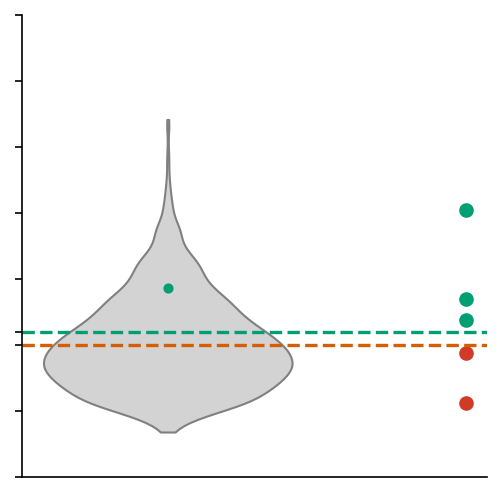

In [81]:
# if thresholdToLabelPositives:
#     activityColName=f'{activityColName}-rescaleZeroTo{pctlmax}'
# print(activityColName)


####################################################################################
# Creaete DFs
####################################################################################

ctrlDF=endf.loc[endf.CONTROL_FUNCTION.notnull(),['CONTROL_FUNCTION','CONTROL_NAME',activityColName]]

# print(ctrlDF)

ctrlDF=ctrlDF.replace(0,np.NaN)

# Subset only controls with good microscope data
if printBadControls==False:
    badControlSlice=ctrlDF.CONTROL_FUNCTION.str.contains('\*')
    unplottedGroups=ctrlDF.CONTROL_FUNCTION.isin(skipControls)
    print(sum(badControlSlice),'controls removed')
    print(' ',', '.join(ctrlDF.loc[badControlSlice,:].index.tolist()))
    ctrlDF=ctrlDF.loc[~badControlSlice & ~unplottedGroups,:]
    
print(len(ctrlDF),'controls used')
    
print(len(ctrlDF),'controls plotted...\n')
print(ctrlDF.CONTROL_NAME.tolist())

# ctrlDF=ctrlDF.set_index('CONTROL_NAME')
endf=endf.set_index('CONTROL_NAME',drop=False)


####################################################################################
# Plot all activities
####################################################################################

activity=activityColName

fig,ax=plt.subplots(1,figsize=(4,4),dpi=150)

#################################
# plot all activity
#################################

print('\tprepping all data...\n')
violinpos=-.3

if not subsampleviolin:
    data=endf[activity].dropna().tolist()
else:
    data=endf[activity].sample(subsampleviolin).dropna().tolist()


rmvalues=set(['inf','-inf',0])
data=[di for di in data if str(di) not in rmvalues]

print('\tplotting all data...\n')
parts=ax.violinplot(data,positions=[violinpos],widths=[.25],showmeans=False, showmedians=False, showextrema=False)
ax.scatter(violinpos,endf.at['OLS WT',activity],s=15,color=cb['green'])
# ax.scatter(violinpos,endf.at['OLS WT_ablatedGataEts',activity],s=15,color=cb['red'])

for pc in parts['bodies']:
    pc.set_facecolor('lightgrey')
    pc.set_edgecolor('grey')
    pc.set_alpha(1)

ax.set_ylabel(activityName)
ax.set_xlabel('')

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)


#################################
# plot controls
#################################

print('\tprepping/plotting control data...\n')

# Create DF for swarmplot (groups on different X)
c2v={'controlname':ctrlDF.CONTROL_NAME,'function':ctrlDF.CONTROL_FUNCTION,'X':[0 for func in ctrlDF.CONTROL_FUNCTION],'Y':ctrlDF[activityColName]}

swarmDF=pd.DataFrame(c2v).dropna()

# print(swarmDF.dropna())

for x,y,func in zipdf(swarmDF,['X','Y','function']):

    color=Func2Color[func]
    ax.scatter(x,y,color=color)

# ax.set_ylim(-12,5)

# sns.swarmplot(data=swarmDF,x='X',y='Y',hue='function',ax=ax,palette=Func2Color,size=6)
# sns.swarmplot(data=swarmDF,x='X',y='Y',ax=ax,size=6)
# ax.spines.right.set_visible(False)
# ax.spines.top.set_visible(False)

# print(ctrlDF.loc[:,['CONTROL_NAME','CONTROL_FUNCTION',activityColName]].sort_values(activityColName).reset_index(drop=True))


# ####################################################################################
# # Legend
# ####################################################################################

# if plot_legend:
#     handles,labels = ax.get_legend_handles_labels()
#     order=['Neural + Ectopic Expression','Neural Enhancer','Weak Neural Enhancer','Non-Functional']
#     order=[labels.index(fxn) for fxn in order if fxn in labels]
#     plt.legend([handles[i] for i in order],[labels[i] for i in order],bbox_to_anchor=(1,1))
# else: ax.get_legend().remove()

# ####################################################################################
# # Plot thresholds for classification
# ####################################################################################

if thresholdToLabelPositives!=None: 
    ax.axhline(1,color=cb['green'],ls='--',lw=1.6)
if thresholdToLabelNegatives!=None: 
    ax.axhline(0,color=cb['red'],ls='--',lw=1.6)


numTotEns=len(endf)
numNullEns=sum(endf[activityColName].isnull())
percenNullEns=percent(numNullEns/len(endf))

numEnsWithActivity=len(endf)-numNullEns

nulEns=endf[activityColName].isnull()
confidentActList=endf.loc[~nulEns,activityColName].tolist()

numFunc=len([i for i in confidentActList if i>0])
numInert=len([i for i in confidentActList if i<=0])

f'{numInert:,} Inert',f'{numFunc:,} Active ens'

activityColTitle=activityColName.replace(aggfunc1,aggfunc1+'\n')


# ax.set_title(title)

# ax.set_ylabel('activity',size=7)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.set_yticks([-10,-5,0,1,5,10,15,20,25])

ax.set_xticklabels([])
ax.set_yticklabels([])

# out='000-science-svgs/v2-2cutoffs_02_PRO_20231120_Enhancer-Activity-Analysis__genomic-activity_2cutoffs.svg'
# plt.savefig(out,format='svg',transparent=True)

plt.show()

In [ ]:
# controlsDetected=['OLS 41 ABL','OLS 85','OG-RC','OLS 12','OLS 19','OLS 11','OLS 22','OLS 29']

In [ ]:
# swarmDF

In [ ]:
# print(activityColName)
# ctrlDF.sort_values(['CONTROL_FUNCTION',activityColName]).loc[:,['CONTROL_NAME','CONTROL_FUNCTION',activityColName]]


In [ ]:
# fn=f'01b-generated-tables/{datestring}-ctrldf-filtered__activity={activityColName}.tsv'
# ctrlDF.sort_values(['CONTROL_FUNCTION',activityColName]).loc[:,['CONTROL_NAME','CONTROL_FUNCTION',activityColName]].to_csv(fn,index=True,sep='\t')


In [ ]:
# activityColName

In [ ]:
# fn=f'v2-2cutoffs_02-activities/{datestring}-endf-filtered__activity={activityColName}'
# endf.loc[:,['enhancer-seq','enhancer-id','CONTROL_NAME','CONTROL_FUNCTION',activityColName]].to_pickle(fn+'.pd.df.pickle')
# endf.loc[:,['enhancer-seq','enhancer-id','CONTROL_NAME','CONTROL_FUNCTION',activityColName]].to_csv(fn+'.tsv',index=False,sep='\t')

In [ ]:
# endf.loc['num-tot-olap'].value_counts()

In [ ]:
# endf.head()

In [ ]:
# endf.head(20)